In [10]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

# Enable LaTeX rendering

plt.rcParams['text.usetex'] = False


In [11]:

def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights


def anomaly(glbmean, normalise = False, detrend = False):
    
    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        linfit = glbmean.polyfit('time',1)
        slope = linfit.polyfit_coefficients.isel(degree = 0)*ns_century

        trend = xr.polyval(coord = glbmean.time, coeffs = linfit.polyfit_coefficients)
        glbmean = glbmean - trend.values +glbmean.mean(dim = 'time')
    
    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim    # detrended interannual annomaly
   

    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name

    return dataanom

def box_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean


In [3]:
#read in w
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp)#.sel(time = slice('1958', '2023'))
w['w'] = w.w*(24*60*60)/100 #convert from Pa/s to hPa/day


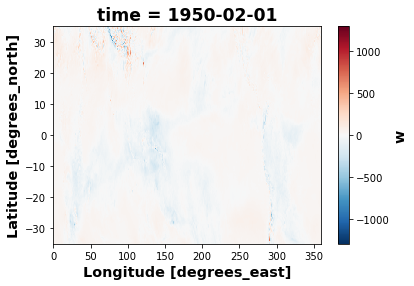

In [4]:
w.isel(time = 1).w.plot()

In [4]:

import numpy as np
import matplotlib.pyplot as plt

def compute_climatology(w):
    # Computing climatology (PDF) for all values in w
    bins = np.linspace(-100, 100, 50)
    hist, _ = np.histogram(w.w.values.flatten(), bins=bins, density=True)
    return hist

def plot_histogram(ax, w, time, climatology):
    # Plotting histograms
    bins = np.linspace(-100, 100, 50)
    hist, _ = np.histogram(w.sel(time=time).w.values.flatten(), bins=bins, density=True)

    # Computing anomalies
    anomalies = hist - climatology

    # Plotting anomalies
    ax.bar(bins[:-1], anomalies, width=np.diff(bins), alpha=0.5, label=str(time))

    # Customizing plot
    ax.set_xlabel('w500 [hPa/day]')
    ax.set_ylabel('Anomaly from Climatology')
    ax.set_title('Year ' + str(time))
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)  # Adding dashed vertical line at x=0
    ax.grid(True)

def plot_monthly_histograms(w, months):

    fig, axs = plt.subplots(len(months), 4, figsize=(16, len(months)*4))
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    fig.suptitle('Monthly Topical circulation S35N35 Anomalies', fontsize=16)

    for i, month in enumerate(months):
        climatology = compute_climatology(w.where(w.time.dt.month ==month))
        for j, year in enumerate(['1982', '1997', '2015', '2023']):
            ax = axs[i, j]
            plot_histogram(ax, w, year+'-'+str(month), climatology)
            ax.legend()

    plt.tight_layout()
    plt.show()

# Assuming you have your xarray data 'w'
months = np.unique(w.time.dt.month)

#plot_monthly_histograms(w, months)


In [5]:
weights = np.cos(np.deg2rad(w.lat))

#tropical atmospheric overturning circulation index
I = abs(w).weighted(weights).mean(['lat', 'lon'])
#hadley circulation index
H = abs(w.mean(dim = 'lon')).weighted(weights).mean('lat')

#walker circulation index
wwest = w.sel(lat = slice(20,-20), lon = slice(110, 200)).where(w.w <0)
weast = w.sel(lat = slice(20,-20), lon = slice(220, 280)).where(w.w >0)
W = wwest.weighted(weights).mean(['lat','lon']) - weast.weighted(weights).mean(dim = ['lat', 'lon'])
W = W/W.std()

In [6]:
W_clim = W.sel(time = slice('1958', '2023')).groupby('time.month').mean()
W_w500 = -(W.groupby('time.month')-W_clim).rolling(time = 3, center = True).mean()
W_w500 = W_w500.rename({'w':'w2c'})

In [7]:
#walker circulation index
wwest = w.sel(lat = slice(15,-15), lon = slice(110, 150)).where(w.w <0)
weast = w.sel(lat = slice(15,-15), lon = slice(220, 280)).where(w.w >0)
W = wwest.weighted(weights).mean(['lat','lon']) - weast.weighted(weights).mean(dim = ['lat', 'lon'])
W = W/W.std()

In [8]:
W_clim = W.sel(time = slice('1958', '2023')).groupby('time.month').mean()
W_w500['w2w'] = -(W.groupby('time.month')-W_clim).rolling(time = 3, center = True).mean().w


In [9]:
W_w500.to_netcdf('/data/jmex/output/circulation/W_w500.nc')

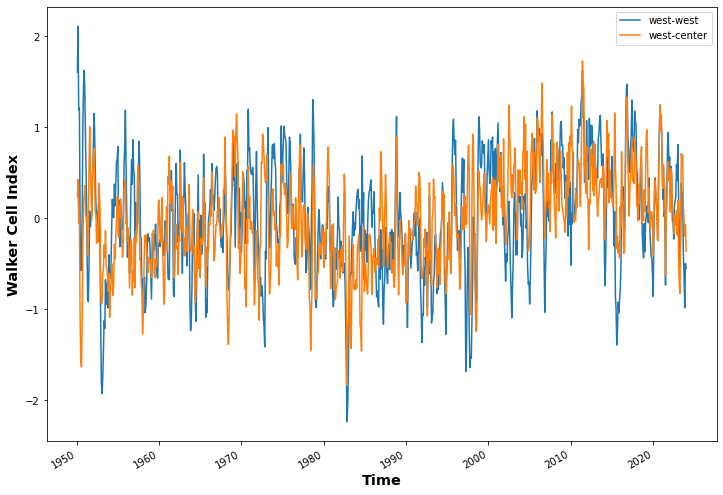

In [10]:
plt.figure(figsize = (12,8))




W_w500.w2w.plot(label = 'west-west')
W_w500.w2c.plot(label = 'west-center')






plt.xlabel('Time')
plt.ylabel('Walker Cell Index')

plt.legend()

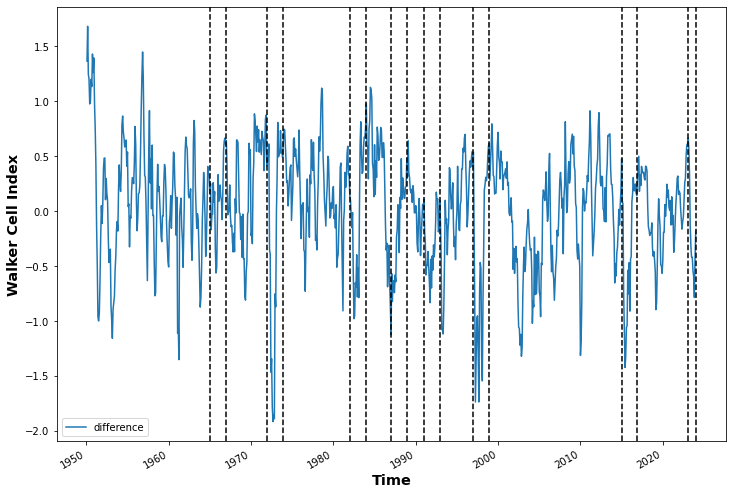

In [11]:
plt.figure(figsize = (12,8))


(W_w500.w2w-W_w500.w2c).plot(label = 'difference')

plt.axvline(W_w500.sel(time = '2023').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '2024').time[-1].data, c = 'k', linestyle = '--')


plt.axvline(W_w500.sel(time = '2015').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '2016').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1997').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1998').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1982').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1983').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1987').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1988').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1991').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1992').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1965').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1966').time[-1].data, c = 'k', linestyle = '--')

plt.axvline(W_w500.sel(time = '1972').time[0].data, c = 'k', linestyle = '--')
plt.axvline(W_w500.sel(time = '1973').time[-1].data, c = 'k', linestyle = '--')

plt.xlabel('Time')
plt.ylabel('Walker Cell Index')

plt.legend()

In [12]:
W_w500.sel(time = '2023').time[-1].data

array('2023-12-01T00:00:00.000000000', dtype='datetime64[ns]')

Text(0, 0.5, 'Walker Circulation Anomaly')

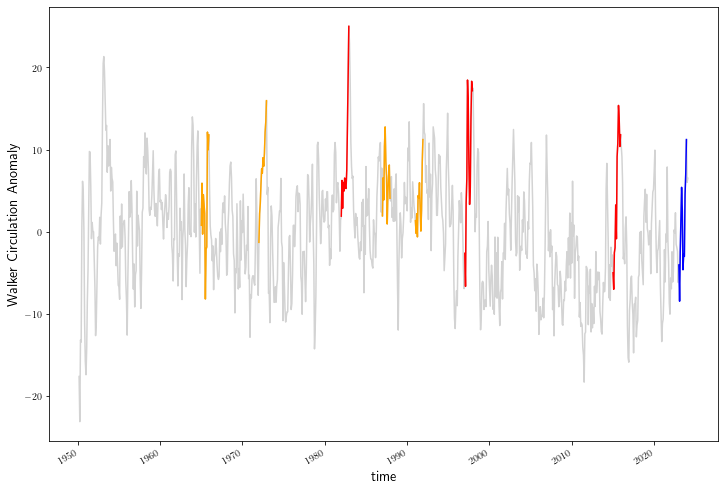

In [17]:


vstrong_ninos = [1982, 1997, 2015]
strong_ninos = [1965, 1972,1987, 1991]



fig, ax = plt.subplots(1,1, figsize = (12,8))


W_anom.w.plot(color = 'lightgrey')

W_sel = W_anom.sel(time = '2023')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w,  color = 'b')


for v in vstrong_ninos:
    W_sel = W_anom.sel(time = str(v))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w,  color = 'r')
    

for s in strong_ninos:
    W_sel = W_anom.sel(time = str(s))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w, color = 'orange')

ax.set_ylabel('Walker Circulation Anomaly')


Text(0, 0.5, 'Walker Circulation Anomaly')

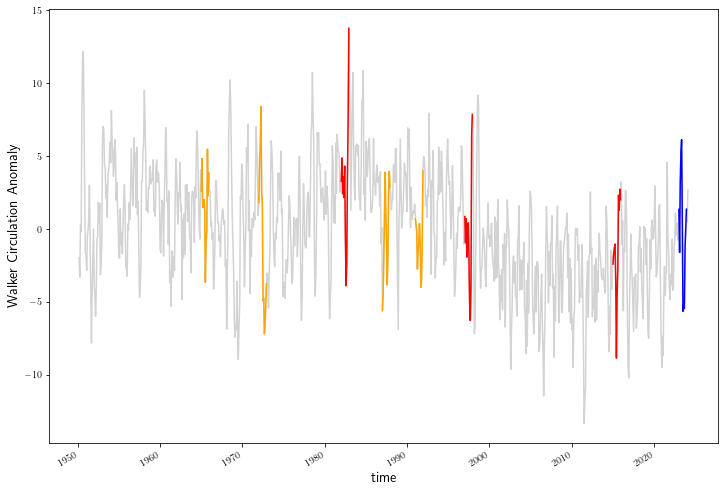

In [20]:


vstrong_ninos = [1982, 1997, 2015]
strong_ninos = [1965, 1972,1987, 1991]


fig, ax = plt.subplots(1,1, figsize = (12,8))


W_anom.w.plot(color = 'lightgrey')

W_sel = W_anom.sel(time = '2023')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w,  color = 'b')


for v in vstrong_ninos:
    W_sel = W_anom.sel(time = str(v))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w,  color = 'r')
    

for s in strong_ninos:
    W_sel = W_anom.sel(time = str(s))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.w, color = 'orange')

ax.set_ylabel('Walker Circulation Anomaly')


No handles with labels found to put in legend.


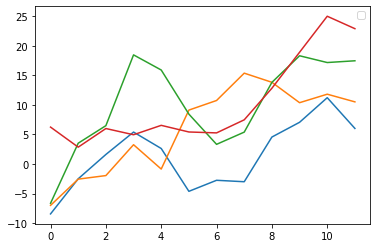

In [63]:
plt.plot(W_anom.w.sel(time = '2023').values)#-W_anom.w.sel(time = '2023').values.mean(), label = '2023')
plt.plot(W_anom.w.sel(time = '2015').values)#-W_anom.w.sel(time = '2015').values.mean(), label = '2015')
plt.plot(W_anom.w.sel(time = '1997').values)#-W_anom.w.sel(time = '1997').values.mean(), label = '1997')

plt.plot(W_anom.w.sel(time = '1982').values)#-W_anom.w.sel(time = '1982').values.mean(), label = '1982')


plt.legend()

In [27]:
I_anom = I.groupby('time.month')-I.groupby('time.month').mean()

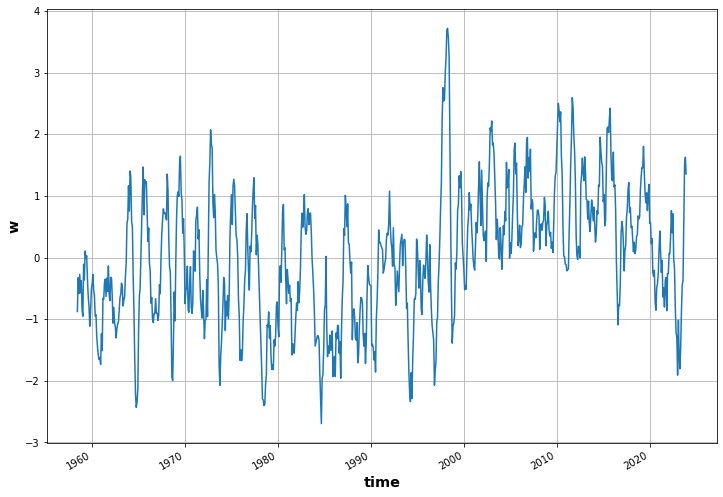

In [14]:
fig, ax = plt.subplots(figsize = (12,8))
ax.grid()
I_anom.rolling(time = 6).mean().w.plot()

In [7]:
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
#take the ND value for each year
ninoND = nino.sel(time = (nino['time.month']>=11)).groupby('time.year').mean(dim = 'time')


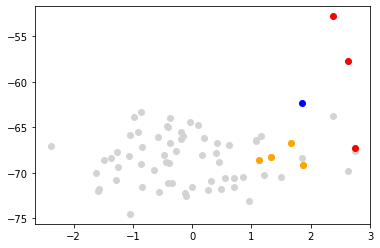

In [25]:
plt.scatter(ninoND.nino34, W.groupby(W.time.dt.year).mean().w, c = 'lightgrey')
plt.scatter(ninoND.sel(year = 1982).nino34, W.sel(time = '1982-10').w.mean(), c = 'r')
plt.scatter(ninoND.sel(year = 1997).nino34, W.sel(time = '1997-10').w.mean(), c = 'r')
plt.scatter(ninoND.sel(year = 2015).nino34, W.sel(time = '2015-10').w.mean(), c = 'r')

for s in [1965, 1972,1987, 1991]:
    plt.scatter(ninoND.sel(year = s).nino34, W.sel(time = str(s)).w.mean(), c = 'orange')

plt.scatter(ninoND.sel(year = 2023).nino34, W.sel(time = '2023-10').w.mean(), c = 'b')

In [ ]:
plt.scatter(nino.nino34, W.w, c = 'lightgrey')
plt.scatter(nino.sel(time = '1982').nino34, W.sel( time = '1982').w, c = 'r')
plt.scatter(nino.sel(time = '1997').nino34, W.sel(time = '1997').w, c = 'r')
plt.scatter(nino.sel(time = '2015').nino34, W.sel(time = '2015').w, c = 'r')

for s in [1965, 1972,1987, 1991]:
    plt.scatter(nino.sel(time = str(s)).nino34, W.sel(time = str(s)).w, c = 'orange')

plt.scatter(nino.sel(time = '2023').nino34, W.sel(time = '2023').w, c = 'b')

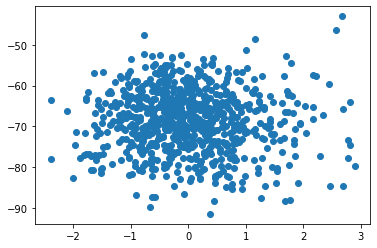

In [13]:
plt.scatter(nino.nino34, W.w)

# Walker Cell based on DElta SLP

Δbox index difference (E − W) of SLP  with box E = (80°W–160°W, 5°S–5°N) and box W = (80°E–160°E, 5°S–5°N)

In [16]:
fp = '/data/jmex/ERA5/monthly/era5_msl.nc'
msl = decode_time(fp)

In [26]:
msl_east = msl.sel(lat = slice(5,-5), lon = slice(200, 280)).weighted(np.cos(np.deg2rad(msl.lat))).mean(dim = ['lat', 'lon'])
msl_west = msl.sel(lat = slice(5,-5), lon = slice(80, 160)).weighted(np.cos(np.deg2rad(msl.lat))).mean(dim = ['lat', 'lon'])
W_slp = msl_east-msl_west


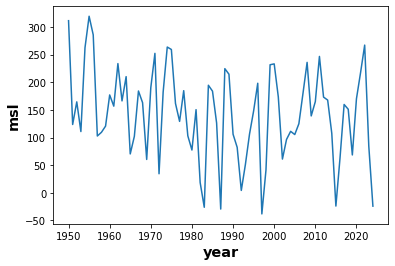

In [27]:
W_slp.groupby('time.year').mean().msl.plot()

In [28]:
W_slp

<xarray.Dataset>
Dimensions:  (time: 889)
Coordinates:
  * time     (time) datetime64[ns] 1950-02-01 1950-03-01 ... 2024-02-01
Data variables:
    msl      (time) float64 254.5 254.6 270.2 235.9 ... 31.59 -24.36 -23.92

Text(0, 0.5, 'W_msl Difference East-West')

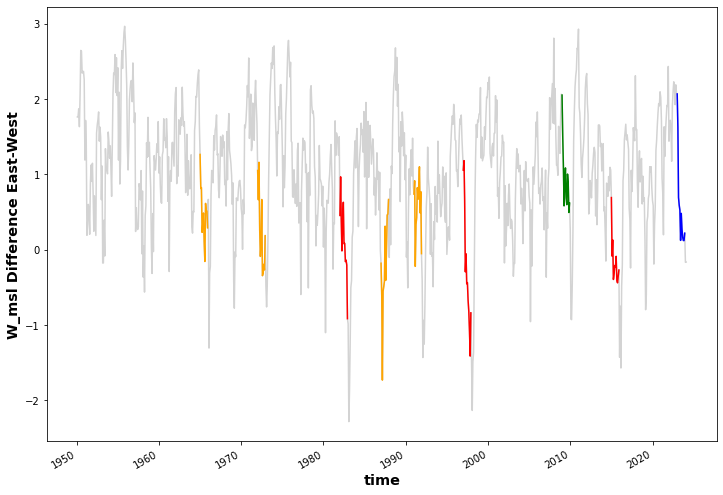

In [49]:
vstrong_ninos = [1982, 1997, 2015]
strong_ninos = [1965, 1972,1987, 1991]


W_slp = W_slp/W_slp.mean()
fig, ax = plt.subplots(1,1, figsize = (12,8))


W_slp.msl.plot(color = 'lightgrey')

W_sel = W_slp.sel(time = '2023')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl,  color = 'b')


for v in vstrong_ninos:
    W_sel = W_slp.sel(time = str(v))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl,  color = 'r')
    

for s in strong_ninos:
    W_sel = W_slp.sel(time = str(s))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl, color = 'orange')
    

W_sel = W_slp.sel(time = '2009')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl, color = 'g')

ax.set_ylabel('W_msl Difference East-West')


# Walker Cell 
Compute Walker cell index based on pressure differences on daily data and save

In [43]:
fp = '/data/jmex/ERA5/daily/era5_msl_daily_80-280E_-5-5N.nc'
msl = xr.open_dataset(fp)

In [45]:
#select time window
msl = msl.sel(time = slice('1958', None))

#select two boxes
#compute weighted average of the two boxes
msl_east = msl.sel(lat = slice(5,-5), lon = slice(200, 280)).weighted(np.cos(np.deg2rad(msl.lat))).mean(dim = ['lat', 'lon'])
msl_west = msl.sel(lat = slice(5,-5), lon = slice(80, 160)).weighted(np.cos(np.deg2rad(msl.lat))).mean(dim = ['lat', 'lon'])

#subtract the box values
W_msl = msl_east-msl_west
#compute the anomaly
W_msl_anom = W_msl-W_msl.mean()

W_msl['anom'] = W_msl_anom.msl




In [46]:
W_msl['anom'] = W_msl_anom.msl


In [47]:
msl

<xarray.Dataset>
Dimensions:  (time: 24166, lon: 400, lat: 20)
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-01-02 ... 2024-02-29
  * lon      (lon) float32 80.12 80.62 81.12 81.62 ... 278.1 278.6 279.1 279.6
  * lat      (lat) float32 4.875 4.375 3.875 3.375 ... -3.625 -4.125 -4.625
Data variables:
    msl      (time, lat, lon) float32 ...
Attributes: (12/21)
    title:                      subset of "ERA5 reanalysis, https://www.ecmwf...
    Conventions:                CF-1.0
    source_field:               https://climexp.knmi.nl/select.cgi?field=era5...
    cdi:                        Climate Data Interface version 2.3.0 (https:/...
    institution:                KNMI Climate Explorer and European Centre for...
    frequency:                  day
    ...                         ...
    geospatial_lon_resolution:  0.5
    time_coverage_start:        1950-01-01
    time_coverage_end:          2024-02-29
    climexp_url:                https://climexp.knmi.nl/select.cgi?era5_msl_d...
    scripturl01:                http://climexp.knmi.nl/get_index.cgi?email=so...
    history:                     2024-04-08 10:07:14 ./bin/get_index ERA5/era...

In [48]:
# save the anomaly

W_msl.to_netcdf('/data/jmex/output/circulation/W_msl.nc')


# Thoughts

The difference between east and west sea level pressure is often used as an indicator of walker cell (e.g. Bayr 2014). 
Usually this difference is positive, meaning the west is at a relative low of sea level and thus sees convergence there. 
Usually this drops strongly for a nino year, thus reversing the circulation. 

The beginning of the drop happens quite early in the year, it preceeds the precipitation shift. Maybe we can thus see it as a precursor/cause for the precipitation shift. 

This time, it di also drop, but the base line was so high, that it is still at the level of the mean more or less, thus not escaping an nino state?

Either way this seems a better indicator (or at least suits me better) than sandrines. 

Next steps: 
make this one into spirals.
Thest on nino and nina state in spirals. 

make a logical/causual story? 


